# WEEK-1 PROJECT-1 
# TELCO CUSTOMERS CHURN PREDICTION 

## 1. Importing Libraries

In [50]:
#  importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib

## 2. Loading Dataset

In [51]:
df = pd.read_csv(r"R:\AI_BOOTCAMP\week1\project1-churn-predictor\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis

In [52]:
df.shape  # check rows and columns
df.head(20)  #check first 20 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [53]:
df.info()  

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [54]:
df.describe()  # shows data which datatype is other than string.

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Data Cleaning

In [55]:
df['TotalCharges'].dtype
df[df['TotalCharges'] == ' ']
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)  # replace empty values with NaN
df['TotalCharges'] = df['TotalCharges'].astype(float)  # change its datatype
df['TotalCharges'] = df['TotalCharges'].fillna(df["TotalCharges"].mean())   # fill the empty(NaN) values with the mean of whole column

In [56]:
# df['TotalCharges'] = df['TotalCharges'].fillna(df["TotalCharges"].mean())   # fill the empty(NaN) values with the mean of whole column

In [57]:
df.isnull().sum()   # check for Null values.

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [58]:
df=df.drop("customerID", axis=1)   # drop column
df.shape # check remaining rows and columns.

(7043, 20)

In [59]:
#Cleaning is done. Now moving to feature engineering. target column "churn"
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [60]:
df['Churn'] = df['Churn'].replace({'No':0,'Yes':1})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [61]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [62]:
df['Churn'] = df['Churn'].astype(int)

In [63]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [64]:
df.select_dtypes(include='object').columns

C:\Users\LENOVO  T470\AppData\Local\Temp\ipykernel_1144\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [65]:
df.select_dtypes(include='object').nunique()

C:\Users\LENOVO  T470\AppData\Local\Temp\ipykernel_1144\3404847108.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64

## 5. Feature Engineering

In [66]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [67]:
df['gender']= df['gender'].replace({'Male':0,'Female':1})
df['gender'].value_counts()

gender
0    3555
1    3488
Name: count, dtype: int64

In [68]:
# df['Partner'].value_counts()
# df['Dependents'].value_counts()
# df['PhoneService'].value_counts()
# df['PaperlessBilling'].value_counts()

In [69]:
# changing all columns with 0 and 1 
df['Partner']= df['Partner'].replace({'No':0,'Yes':1})
df['Dependents']= df['Dependents'].replace({'No':0,'Yes':1})
df['PhoneService']= df['PhoneService'].replace({'No':0,'Yes':1})
df['PaperlessBilling']= df['PaperlessBilling'].replace({'No':0,'Yes':1})

# converting them into binary
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
df[binary_cols] = df[binary_cols].astype(int)

In [70]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [71]:
# now handling multi-columns with one-hot-encoding
pd.get_dummies(df['Contract'])

,Month-to-month,One year,Two year
0,True,False,False
1,False,True,False
2,True,False,False
3,False,True,False
4,True,False,False
...,...,...,...
7038,False,True,False
7039,False,True,False
7040,True,False,False
7041,True,False,False


In [72]:
df = pd.get_dummies(df, columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'])


In [73]:
df.shape

(7043, 41)

In [74]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


In [75]:
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


In [76]:
df.dtypes.value_counts()

int64      39
float64     2
Name: count, dtype: int64

## 6. Train Test Split

In [77]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42) 

In [79]:
print(X_train.shape) #train test split confirm
print(X_test.shape)

(5634, 40)
(1409, 40)


## 7. Handling Class Imbalance (SMOTE)

In [80]:
from imblearn.over_sampling import SMOTE

In [81]:
#applying SMOTE to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


In [82]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(
        n_estimators=700,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.75,
        min_child_weight=2,
        gamma=0.05,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [83]:
# class Imbalanced fixed now both have same values
#Now retrain the pipeline on the SMOTE data
pipeline.fit(X_train_smote, y_train_smote)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1036
           1       0.62      0.57      0.59       373

    accuracy                           0.79      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [84]:
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_pred_proba >= 0.45).astype(int)
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1036
           1       0.61      0.62      0.61       373

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.79      1409



## 8. Model Training

In [85]:
#NEW PIPELINE
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(
        n_estimators=700,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.75,
        min_child_weight=2,
        gamma=0.05,
        random_state=42,
        eval_metric='logloss'
    ))
])

pipeline.fit(X_train_smote, y_train_smote)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1036
           1       0.62      0.57      0.59       373

    accuracy                           0.79      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [86]:
y_pred_tuned = (y_pred_proba >= 0.30).astype(int)
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1036
           1       0.54      0.77      0.64       373

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



## 9. Model Validation

In [87]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

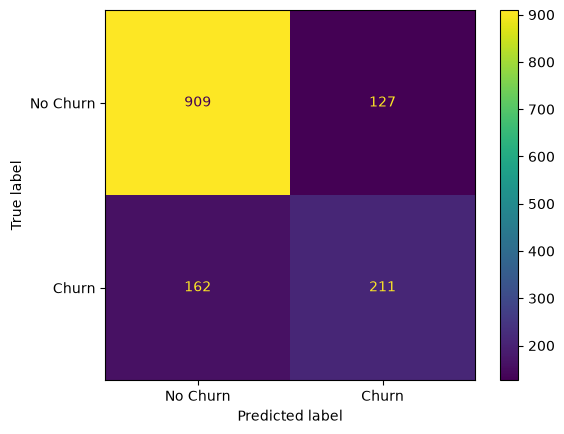

In [88]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot()

In [89]:
#ROC score
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, y_pred_proba))


0.8437600277412609


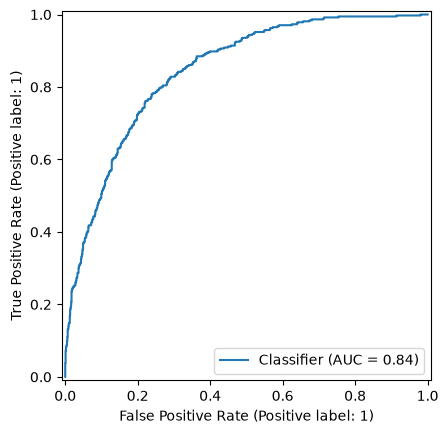

In [90]:
#ROC_CURVE
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred_proba)

## 10. Saving Model

In [91]:
joblib.dump(pipeline, r"R:\AI_BOOTCAMP\week1\project1-churn-predictor\models\churn_model.pkl")

['R:\\AI_BOOTCAMP\\week1\\project1-churn-predictor\\models\\churn_model.pkl']